## Sentiment Analysis

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SimpleRNN
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.utils import to_categorical
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
data = pd.read_csv('/content/Twitter_Data.csv')
data.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


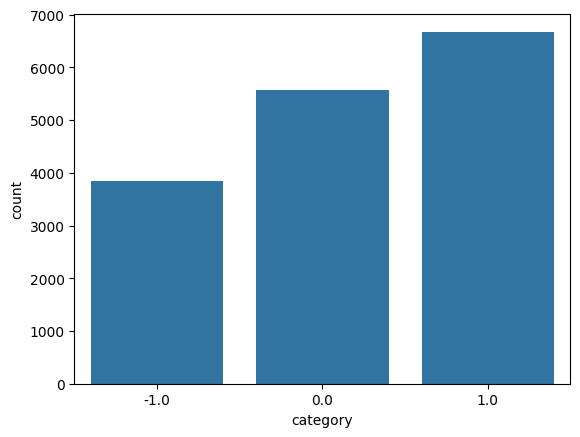

In [5]:
sns.countplot(x='category', data=data)
plt.show()

In [6]:
data.dropna(how='any', inplace=True)
data.isnull().sum()

,0
clean_text,0
category,0


In [7]:
texts = data['clean_text'].tolist()
labels = data['category'].tolist()

In [8]:
#Text preprocessing - stopwords removal and porter stemming algorithm

In [9]:
# Text preprocessing
def preprocess_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    text = text.lower()
    tokens = text.split()

    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]

    stemmer = PorterStemmer()
    tokens = [stemmer.stem(token) for token in tokens]

    return ' '.join(tokens)

In [10]:
preprocessed_texts = [preprocess_text(text) for text in texts]

In [11]:
#Tokenization and fixing the vocabulary size
# Tokenization and word embeddings
vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(preprocessed_texts)
sequences = tokenizer.texts_to_sequences(preprocessed_texts)

In [12]:
# Padding sequences
max_length = 80
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

In [13]:
#One hot encoding
# Prepare labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
num_classes = len(set(labels))
one_hot_labels = to_categorical(encoded_labels)

In [14]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, one_hot_labels, test_size=0.2, random_state=42)

In [15]:
#Construct the sequential model RNN and LSTM

In [16]:
class_names = {"-1":"Negative", "0":"Neutral", "1":"Positive"}

In [17]:
# Build LSTM + RNN model
embedding_dim = 16

model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_length),
    Bidirectional(LSTM(32, return_sequences=True)),
    Bidirectional(SimpleRNN(32)),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [18]:
history = model.fit(X_train, y_train, epochs=5, validation_split=0.1, batch_size=32, verbose=1)

Epoch 1/5
362/362 ━━━━━━━━━━━━━━━━━━━━ 40s 89ms/step - accuracy: 0.5474 - loss: 0.5600 - val_accuracy: 0.6138 - val_loss: 0.5158
Epoch 2/5
362/362 ━━━━━━━━━━━━━━━━━━━━ 33s 92ms/step - accuracy: 0.6655 - loss: 0.4446 - val_accuracy: 0.6573 - val_loss: 0.4492
Epoch 3/5
362/362 ━━━━━━━━━━━━━━━━━━━━ 32s 89ms/step - accuracy: 0.7632 - loss: 0.3490 - val_accuracy: 0.6232 - val_loss: 0.4974
Epoch 4/5
362/362 ━━━━━━━━━━━━━━━━━━━━ 34s 94ms/step - accuracy: 0.8436 - loss: 0.2622 - val_accuracy: 0.7615 - val_loss: 0.3986
Epoch 5/5
362/362 ━━━━━━━━━━━━━━━━━━━━ 32s 89ms/step - accuracy: 0.9066 - loss: 0.1771 - val_accuracy: 0.7607 - val_loss: 0.4186


In [19]:
# Evaluate RNN model
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc}")

101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7750 - loss: 0.4036
Test Accuracy: 0.7750155329704285


In [20]:
def preprocess_text(text):
    # Convert text to sequence of integers
    sequence = tokenizer.texts_to_sequences([text])

    # Pad the sequence to match the input length used during training
    padded_sequence = pad_sequences(sequence, maxlen=max_length)

    return padded_sequence

# Now you can predict
text = "The movie was sooo good. The cast outdid themselves"
processed_text = preprocess_text(text)
prediction = model.predict(processed_text)

# Interpret the prediction (depends on your specific task)
print(class_names[f'{np.argmax(prediction)}'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step
Positive
